## Here, we are implementing Gradient Descent from scratch

Prerequisites : Calculus, Derivatives and partial derivatives

We use two libaries Numpy and Matplotlib                                    


In [1]:

import numpy as np
import matplotlib.pyplot as plt

Initialize a function, in our case we use f(x) = X**2, a U-shped curve for our understanding. But for neural networks this function will be replaced by a cost function. The only thing is you have to understand how it works, that's it !! 

In [2]:
def y_function(x):
    return x**2

In [3]:
# Defining the derivative of the function
def y_derivative(x):
    return 2 * x

The visual of the Funtion is as follows, just see how the function looks like, no need to study how to implement this !!

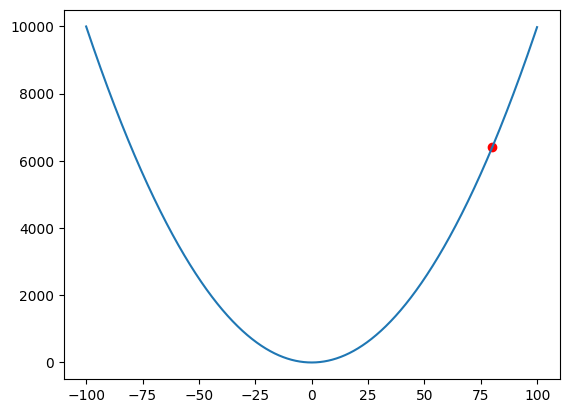

In [4]:
# Visuals of the function and its derivative
x = np.arange(-100, 100, 0.1)
y = y_function(x)

current_pos = (80, y_function(80))

plt.plot(x,y)
plt.scatter(current_pos[0], current_pos[1], color='red') # Starting point
plt.show()


### **The Intuition Behind Gradient Descent**

* **Derivative as Slope**: The derivative represents the slope of the curve at a specific point. For our function $y = x^2$, the derivative is $2x$. This tells us how much our error ($y$) changes for every small step we take in our weights ($x$).
* **Positive Slope Example**: In this graph, at **$x = 80$**, the slope is **$+160$** ($2 \times 80$). Because the sign is positive, the red dot is on the right side of the "U," meaning we are currently "uphill."
* **Direction of Movement**: To reach the minimum (the bottom of the U), we must move in the opposite direction of the slope. Since our slope is $+160$, we must **decrease** the weight to move toward zero.
* **The Sign is the Key**: The sign of the slope acts as our compass. A **positive slope** tells us to decrease the weights, while a **negative slope** (on the left side) would tell us to increase the weights.
* **Reaching the Descent**: By using the update rule $x = x - (\text{learning\_rate} \times \text{slope})$, we automatically "descend" the curve. As the red dot gets closer to the bottom, the slope gets smaller, causing our steps to slow down naturally as we reach the lowest error.



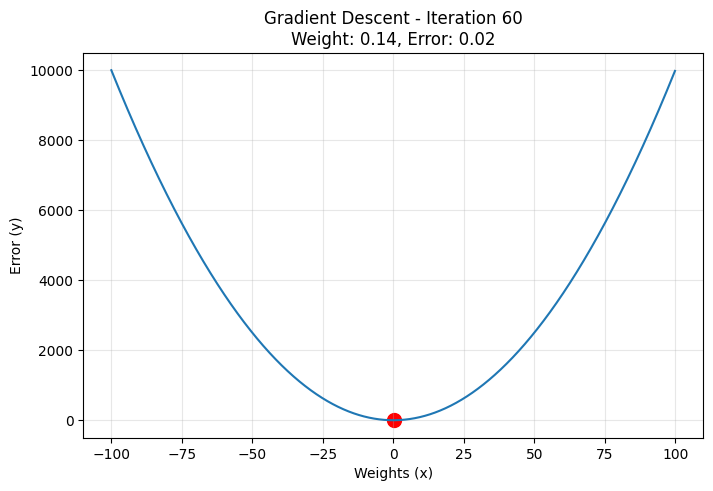

In [5]:
import time
from IPython.display import clear_output 

# Set initial position again so we don't start at 0
current_pos = [80, y_function(80)]
lr = 0.05 # Increased lr slightly for a more visible jump

for i in range(60):
    # 1. Calculate new position
    new_x = current_pos[0] - lr * y_derivative(current_pos[0])
    new_y = y_function(new_x)
    current_pos = [new_x, new_y]
    
    # 2. Clear the previous plot
    clear_output(wait=True)
    
    # 3. Draw the frame
    plt.figure(figsize=(8, 5))
    plt.plot(x, y, label='Cost Function ($x^2$)')
    plt.scatter(current_pos[0], current_pos[1], color='red', s=100)
    plt.title(f"Gradient Descent - Iteration {i+1}\nWeight: {current_pos[0]:.2f}, Error: {current_pos[1]:.2f}")
    plt.xlabel("Weights (x)")
    plt.ylabel("Error (y)")
    plt.grid(True, alpha=0.3)
    
    plt.show() 
    
    # 4. ADD THIS: Tiny pause so the human eye can see the movement
    time.sleep(0.5)  # Adjust this for faster/slower animation


The thing is we calculating the derivative for each weights and biases and then we will act accordingly whether to increase or decrease. This is the concept and this is how neural networks learns

Now, let's change the learning rate and see how it looks like 

Decreasing the learning rate from 0.05 to 0.001

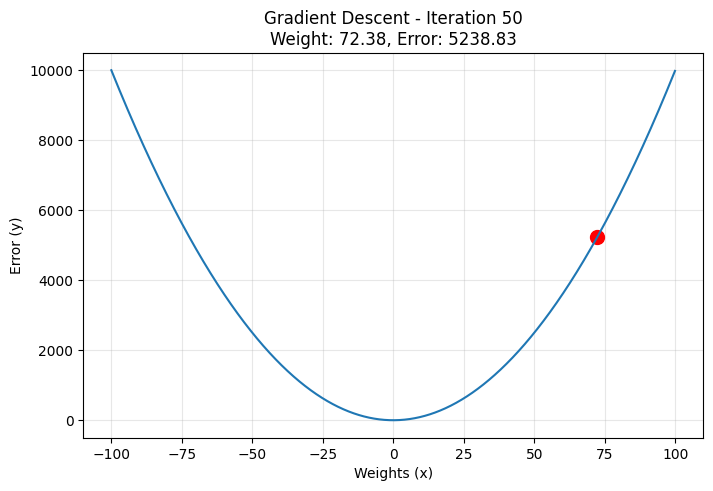

In [6]:
import time
from IPython.display import clear_output 

# Set initial position again so we don't start at 0
current_pos = [80, y_function(80)]
lr = 0.001 # Deacresing the learning rate smaller
for i in range(50):
    # 1. Calculate new position
    new_x = current_pos[0] - lr * y_derivative(current_pos[0])
    new_y = y_function(new_x)
    current_pos = [new_x, new_y]
    
    # 2. Clear the previous plot
    clear_output(wait=True)
    
    # 3. Draw the frame
    plt.figure(figsize=(8, 5))
    plt.plot(x, y, label='Cost Function ($x^2$)')
    plt.scatter(current_pos[0], current_pos[1], color='red', s=100)
    plt.title(f"Gradient Descent - Iteration {i+1}\nWeight: {current_pos[0]:.2f}, Error: {current_pos[1]:.2f}")
    plt.xlabel("Weights (x)")
    plt.ylabel("Error (y)")
    plt.grid(True, alpha=0.3)
    
    plt.show() 
    
    # 4. ADD THIS: Tiny pause so the human eye can see the movement
    time.sleep(0.5) 

You can see when we reduce the learning rate, the model converges slowly to the minimum error.

Increasing the learning rate from 0.001 to 1

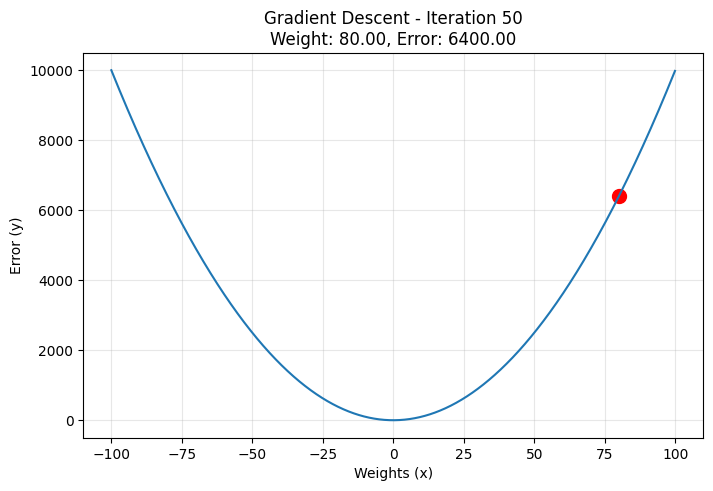

In [7]:
import time
from IPython.display import clear_output 

# Set initial position again so we don't start at 0
current_pos = [80, y_function(80)]
lr = 1 # Deacresing the learning rate smaller
for i in range(50):
    # 1. Calculate new position
    new_x = current_pos[0] - lr * y_derivative(current_pos[0])
    new_y = y_function(new_x)
    current_pos = [new_x, new_y]
    
    # 2. Clear the previous plot
    clear_output(wait=True)
    
    # 3. Draw the frame
    plt.figure(figsize=(8, 5))
    plt.plot(x, y, label='Cost Function ($x^2$)')
    plt.scatter(current_pos[0], current_pos[1], color='red', s=100)
    plt.title(f"Gradient Descent - Iteration {i+1}\nWeight: {current_pos[0]:.2f}, Error: {current_pos[1]:.2f}")
    plt.xlabel("Weights (x)")
    plt.ylabel("Error (y)")
    plt.grid(True, alpha=0.3)
    
    plt.show() 
    
    # 4. ADD THIS: Tiny pause so the human eye can see the movement
    time.sleep(0.5) 

Now, you can conclude that learning rate is a crucial hyperparameter to consider. When you increase the rate, it never converges to a lower point also when you reduce the value too low, the model will take long time to converge. Understanding this can help you find the "sweet spot" where your model learns efficiently without overshooting the minimum or getting stuck in endless, tiny steps.
By balancing speed and stability, you ensure the gradient descent process is both accurate and computationally fast.

### **Global vs. Local Minima**

* **Global Minima**: The absolute "rock bottom." This is the best possible version of your model with the lowest error.
* **Local Minima**: A valley that looks like the bottom but isn't. Gradient Descent can get "trapped" here because the slope becomes zero, making the model stop learning prematurely.


So, you will do for multiple dimensions but the intuition is the same

So, let's go ahead and turn this into a 3D visualization 

In [8]:
import numpy as np
import matplotlib.pyplot as plt

The below function is just a complex function which has so many curves

In [9]:
def z_function(x, y):
    return np.sin(5*x) * np.cos(5*y) / 5

The below function is the partial derivative of that complex function. If you don't know partial derivative then I will tell you.                             We will differentiate one variable by keeping the other variable as constant 

Here when we differentiate sin(x) we will keep cos(x) as constant and while differentiate cos(x) we keep sin(x) as constant

In [10]:
def calculate_gradient(x, y):
    return np.cos(5*x) * np.cos(5*y), -np.sin(5*x) * np.sin(5*y)

In [11]:
x = np.arange(-1, 1, 0.05)
y = np.arange(-1, 1, 0.05)

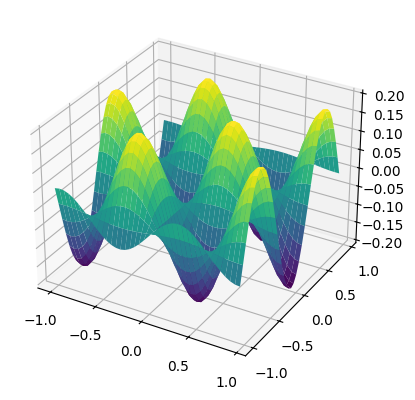

In [12]:
X, Y = np.meshgrid(x, y)
Z = z_function(X, Y)

ax = plt.subplot(projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
plt.show()


In this function there are lot of local minima, we want to find the Global minima. Let's do that

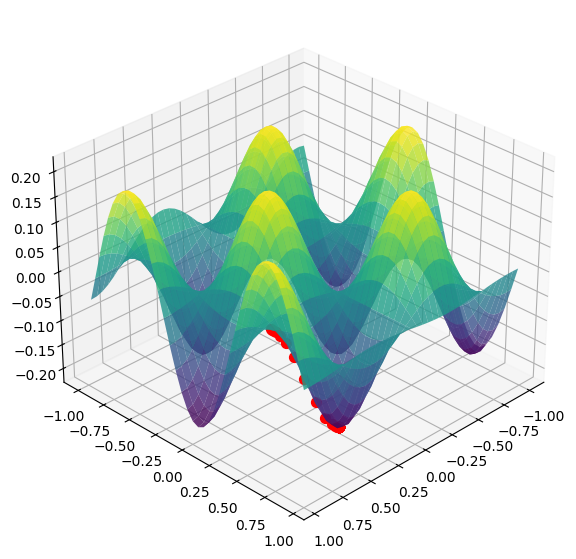

In [13]:
%matplotlib qt5
import matplotlib.pyplot as plt
from IPython.display import clear_output

# 1. Setup the initial figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 2. Plot the surface ONCE outside the loop (saves memory/time)
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.view_init(elev=30, azim=45) # Set a good viewing angle

current_pos = (0.7, 0.4, z_function(0.7, 0.4))
l_rate = 0.1

# 3. The Optimization Loop
for _ in range(100):
    # Calculate gradients
    X_derivative, Y_derivative = calculate_gradient(current_pos[0], current_pos[1])
    X_new = current_pos[0] - l_rate * X_derivative
    Y_new = current_pos[1] - l_rate * Y_derivative
    current_pos = (X_new, Y_new, z_function(X_new, Y_new))
    
    # Plot the new point
    # We use 'zorder' to make sure the red dot stays on top of the surface
    point = ax.scatter(current_pos[0], current_pos[1], current_pos[2], color='red', s=50, zorder=10)
    
    # Update the display
    display(fig)
    clear_output(wait=True)



From here you can see that in 3D, there are lot of local minima are there. We will find the global minima by placing the weights or just place the starting point in all the curves simultaneously to get the global minima. 

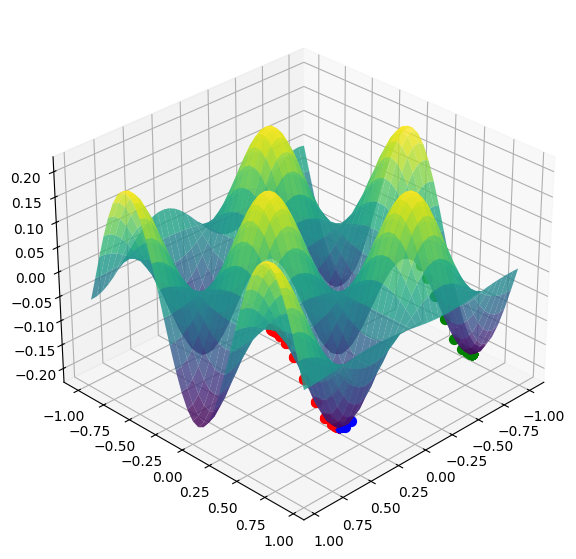

In [14]:
current_pos1 = (0.7, 0.4, z_function(0.7, 0.4))
current_pos2 = (0.3, 0.8, z_function(0.3, 0.8))
current_pos3 = (-0.5, 0.5, z_function(-0.5, 0.5))

l_rate = 0.1

for _ in range(100):
    # Calculate gradients
    X_derivative, Y_derivative = calculate_gradient(current_pos1[0], current_pos1[1])
    X_new = current_pos1[0] - l_rate * X_derivative
    Y_new = current_pos1[1] - l_rate * Y_derivative
    current_pos1 = (X_new, Y_new, z_function(X_new, Y_new))

    # Calculate gradients for current_pos2
    X_derivative, Y_derivative = calculate_gradient(current_pos2[0], current_pos2[1])
    X_new = current_pos2[0] - l_rate * X_derivative
    Y_new = current_pos2[1] - l_rate * Y_derivative
    current_pos2 = (X_new, Y_new, z_function(X_new, Y_new))

    # Calculate gradients for current_pos3
    X_derivative, Y_derivative = calculate_gradient(current_pos3[0], current_pos3[1])
    X_new = current_pos3[0] - l_rate * X_derivative
    Y_new = current_pos3[1] - l_rate * Y_derivative
    current_pos3 = (X_new, Y_new, z_function(X_new, Y_new))

    # Plot the new point
    # We use 'zorder' to make sure the red dot stays on top of the surface
    point = ax.scatter(current_pos1[0], current_pos1[1], current_pos1[2], color='red', s=50, zorder=10)
    point = ax.scatter(current_pos2[0], current_pos2[1], current_pos2[2], color='blue', s=50, zorder=10)
    point = ax.scatter(current_pos3[0], current_pos3[1], current_pos3[2], color='green', s=50, zorder=10)

    # Update the display
    display(fig)
    clear_output(wait=True)

## So, from here you get to know about the Gradient Descent and what is the math behind and how it works and finds the minimum error. This is how neural Networks learn by changing the weights and bias to get teh lowest possible error

## Run this file and see the visualization of gradient descent in action on a 2D and 3D surface! Without running the file you won't undertand how the learning rate is important, what exactly is the Gradient, how it finds the lowest error.